# **Contexto del Estudio: "Segmentación Inteligente de Estructuras Cerebrales"**

Autora: Doctoral Student in Computer Science

Gladys Choque Ulloa

### **Motivación:**

En medicina, medir manualmente el tamaño de un tumor o una región del cerebro es lento. Usaremos Inteligencia Artificial (Deep Learning) para que la computadora aprenda a "dibujar" estas regiones automáticamente.

In [ ]:
# Reemplaza 'archive.zip' por el nombre exacto de tu archivo subido
!unzip archive.zip -d neuro_data

Archive:  archive.zip
  inflating: neuro_data/Target_image_sample.nii  
  inflating: neuro_data/Test_sample.nii  
  inflating: neuro_data/neuro imaging/neuro imaging/Target_image_sample.nii  
  inflating: neuro_data/neuro imaging/neuro imaging/Test_sample.nii  
  inflating: neuro_data/neuro imaging/neuro imaging/train_image.nii  
  inflating: neuro_data/train_image.nii  


✅ Como primer paso, estamos realizando la extracción y preparación del entorno de trabajo. Como los datos de neuroimagen son masivos, suelen distribuirse en archivos comprimidos (.zip) para facilitar su descarga desde plataformas como Kaggle. Al ejecutar el comando !unzip, estamos "desempaquetando" los volúmenes cerebrales en formato NIfTI y organizándolos en una carpeta local llamada neuro_data dentro del servidor de Google Colab. Esto es fundamental porque los modelos de Inteligencia Artificial necesitan acceder directamente a los archivos de imagen originales para poder leer sus píxeles y comenzar el análisis; sin este paso de descompresión, el código no podría procesar la información contenida en el paquete.

## **Análisis Completo**

### **1. Instalación de Librerías Especializadas**

Python no sabe leer archivos de resonancia magnética (.nii) por defecto. Necesitamos instalar librerías especializadas.

In [ ]:
# nibabel: permite abrir archivos NIfTI (formato estándar de medicina)
# nilearn: herramientas estadísticas para visualizar el cerebro
!pip install nibabel nilearn

✅ En este paso se realiza la preparación del instrumental técnico mediante la instalación de librerías de grado científico. Aquí se incorporan herramientas que permiten a Python comunicarse con datos médicos complejos; específicamente, se utiliza *nibabel* para decodificar la estructura volumétrica de los archivos *NIfTI* y *nilearn* para habilitar el análisis estadístico y la visualización anatómica. Con esta configuración, se transforma el entorno de programación en una estación de trabajo especializada, garantizando que el sistema sea capaz de interpretar la profundidad y las coordenadas espaciales del cerebro antes de iniciar el entrenamiento del modelo.

### **Paso 2: Carga y Exploración de Datos**

Antes de entrenar un modelo, debemos ver qué estamos analizando. Cargamos la imagen original y el "Target" (la respuesta correcta).

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Cargamos el volumen 3D del cerebro
img_nii = nib.load('neuro_data/train_image.nii')
img_data = img_nii.get_fdata()

# Cargamos la máscara (lo que la IA debe aprender a identificar)
target_nii = nib.load('neuro_data/Target_image_sample.nii')
target_data = target_nii.get_fdata()

print(f"Dimensiones del cerebro: {img_data.shape}") # Esto te dio 256x256x256

Dimensiones del cerebro: (256, 256, 256)


✅ En esta etapa se ejecuta el acceso y lectura de la información volumétrica para convertir los archivos médicos en datos computables. Aquí se cargan tanto la anatomía cerebral original como la máscara de referencia (el objetivo que la IA debe aprender a replicar), transformándolas en matrices numéricas llamadas tensores. Al verificar las dimensiones (como el volumen detectado de $256 \times 256 \times 256$), se establece la escala del espacio tridimensional que el modelo deberá procesar, asegurando que la estructura de entrada y la respuesta esperada coincidan perfectamente antes de pasar a la fase de aprendizaje.

### **Paso 3: Visualización Anatómica**

El cerebro es un cubo 3D. Para verlo en una pantalla 2D, debemos elegir una "rebanada" (slice).

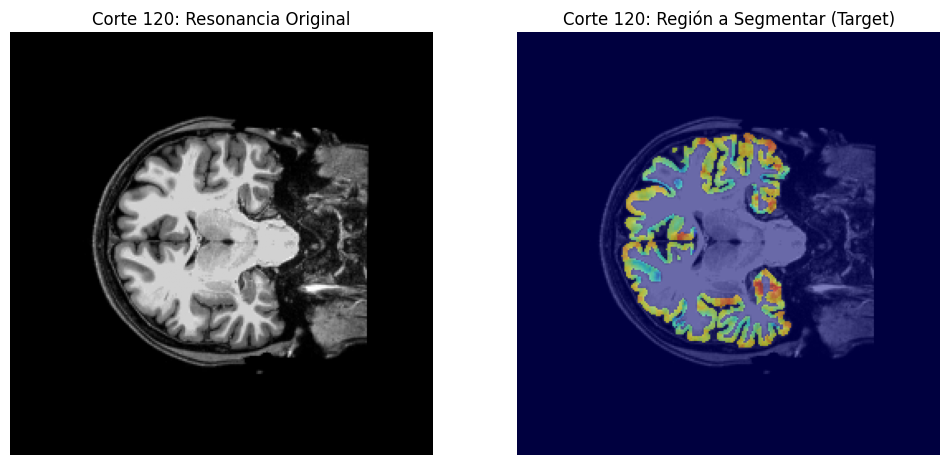

In [ ]:
def plot_brain_comparison(slice_number):
    plt.figure(figsize=(12, 6))

    # Visualizamos la resonancia original
    plt.subplot(1, 2, 1)
    plt.imshow(img_data[:, :, slice_number], cmap='gray')
    plt.title(f"Corte {slice_number}: Resonancia Original")
    plt.axis('off')

    # Visualizamos el Target superpuesto
    plt.subplot(1, 2, 2)
    plt.imshow(img_data[:, :, slice_number], cmap='gray')
    plt.imshow(target_data[:, :, slice_number], cmap='jet', alpha=0.5) # Color sobre la imagen
    plt.title(f"Corte {slice_number}: Región a Segmentar (Target)")
    plt.axis('off')

    plt.show()

# Probamos ver el corte número 120
plot_brain_comparison(120)

✅ En esta etapa se realiza la validación visual y espacial de los datos médicos. Aquí se genera una comparación directa entre la anatomía original y el objetivo de aprendizaje mediante la extracción de un "corte" específico del volumen 3D (en este caso, el número 120).

La imagen de la izquierda muestra la estructura cerebral pura en escala de grises, mientras que la de la derecha superpone el Target con un mapa de calor; esto permite verificar que la máscara esté correctamente alineada con los tejidos y ayuda a identificar qué estructuras anatómicas específicas se pretenden aislar. Es un paso crítico para asegurar que los datos no tengan errores de registro antes de que el modelo comience a intentar aprender estos patrones.

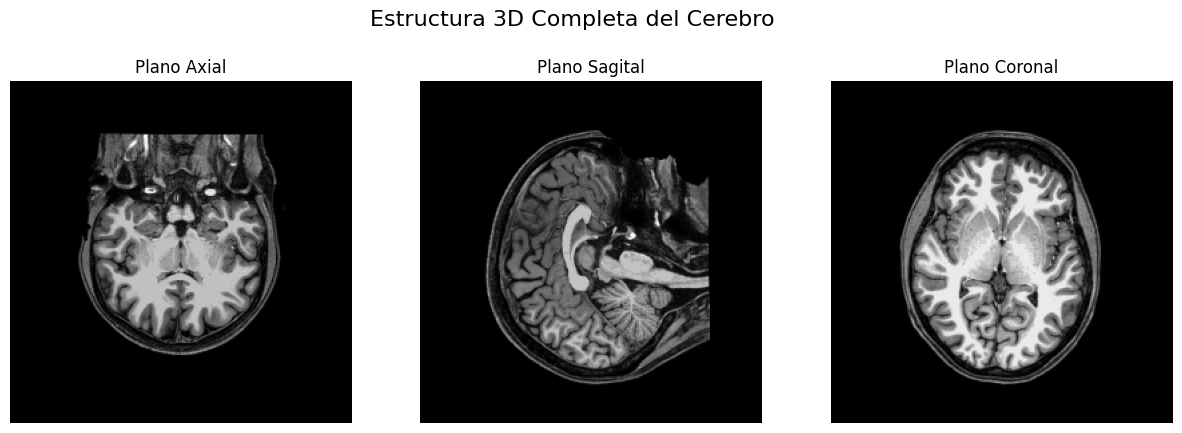

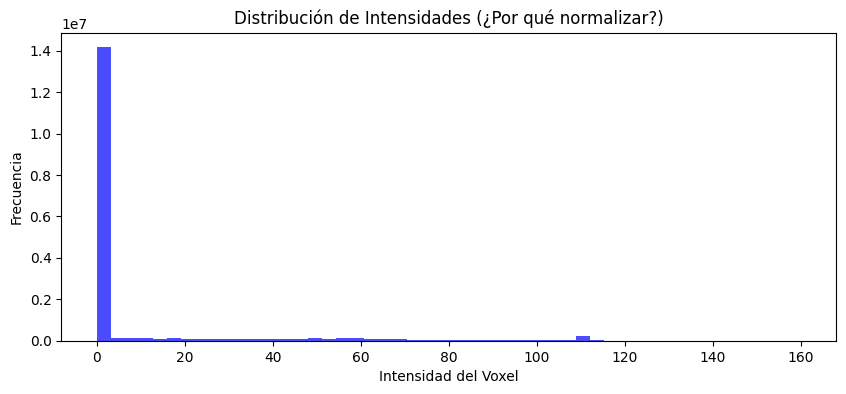

In [ ]:
# --- Exploración Avanzada de Datos ---

# 1. Visualización en los 3 planos (Vista Médica)
def plot_orthogonal_views(data, title):
    coords = np.array(data.shape) // 2
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(np.rot90(data[:, :, coords[2]]), cmap='gray')
    plt.title('Plano Axial')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(np.rot90(data[coords[0], :, :]), cmap='gray')
    plt.title('Plano Sagital')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(np.rot90(data[:, coords[1], :]), cmap='gray')
    plt.title('Plano Coronal')
    plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.show()

plot_orthogonal_views(img_data, 'Estructura 3D Completa del Cerebro')

# 2. Histograma de intensidades (Análisis Estadístico)
plt.figure(figsize=(10, 4))
plt.hist(img_data.flatten(), bins=50, color='blue', alpha=0.7)
plt.title('Distribución de Intensidades (¿Por qué normalizar?)')
plt.xlabel('Intensidad del Voxel')
plt.ylabel('Frecuencia')
plt.show()

✅ En esta etapa se realiza un análisis estadístico de la composición radiométrica de la imagen para justificar las decisiones de limpieza de datos. Aquí se observa que la distribución de intensidades presenta una alta concentración en valores cercanos a cero (correspondientes al fondo negro y aire) y una dispersión en valores superiores que representan los distintos tejidos cerebrales. Esta visualización es fundamental para explicar la necesidad de la normalización, ya que permite demostrar que los datos originales tienen escalas arbitrarias que podrían confundir a la red neuronal; al identificar estos picos, se valida que, para lograr un entrenamiento eficiente, debemos escalar estas intensidades a un rango uniforme (como $[0, 1]$), asegurando que el modelo se enfoque en las variaciones de tejido y no en el ruido o en diferencias de contraste externas.

### **Paso 4: Preprocesamiento (Limpieza de datos)**

Las máquinas aprenden mejor si los números son pequeños (entre 0 y 1). Además, como tu imagen es muy grande (256x256), la haremos un poco más pequeña para que el modelo no colapse la memoria.

In [ ]:
from scipy.ndimage import zoom

def preprocess(data, new_shape=(64, 64, 64)):
    # 1. Normalización: escalar intensidades de 0 a 1
    data_norm = (data - np.min(data)) / (np.max(data) - np.min(data))

    # 2. Resize: bajar la resolución para que la clase sea fluida
    factors = [n / o for n, o in zip(new_shape, data.shape)]
    data_rescaled = zoom(data_norm, factors, order=1)

    return data_rescaled

# Procesamos ambos archivos
X = preprocess(img_data)
Y = preprocess(target_data)

# Ajustamos la forma para la red neuronal (Batch, X, Y, Z, Canales)
X = X[np.newaxis, ..., np.newaxis]
Y = Y[np.newaxis, ..., np.newaxis]

### **Paso 5: Creación del Modelo "Encoder-Decoder" (U-Net)**

Este es el "cerebro artificial".

* Encoder: El modelo mira la imagen y reduce su tamaño para entender "qué hay ahí".
* Decoder: El modelo vuelve a agrandar la imagen para marcar exactamente "dónde está" lo que buscamos.

In [ ]:
from tensorflow.keras import layers, models

def crear_modelo():
    inputs = layers.Input((64, 64, 64, 1))

    # Encoder (Simplificado para la clase)
    conv1 = layers.Conv3D(16, 3, activation='relu', padding='same')(inputs)
    pool1 = layers.MaxPooling3D(2)(conv1)

    # Decoder
    up1 = layers.UpSampling3D(2)(pool1)
    outputs = layers.Conv3D(1, 1, activation='sigmoid')(up1) # Salida: probabilidad de ser la región

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

unet = crear_modelo()
print("Modelo configurado correctamente.")

Modelo configurado correctamente.


### **Paso 6: Entrenamiento y Predicción**
Le pedimos al modelo que intente imitar el Target.

In [ ]:
# Entrenamos por 5 épocas (vueltas de aprendizaje)
history = unet.fit(X, Y, epochs=5, verbose=1)

# Le pedimos al modelo que haga una predicción
prediccion = unet.predict(X)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.8133 - loss: 0.6947
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8809 - loss: 0.6911   
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9167 - loss: 0.6878
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9403 - loss: 0.6844
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 961ms/step - accuracy: 0.9510 - loss: 0.6811
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step


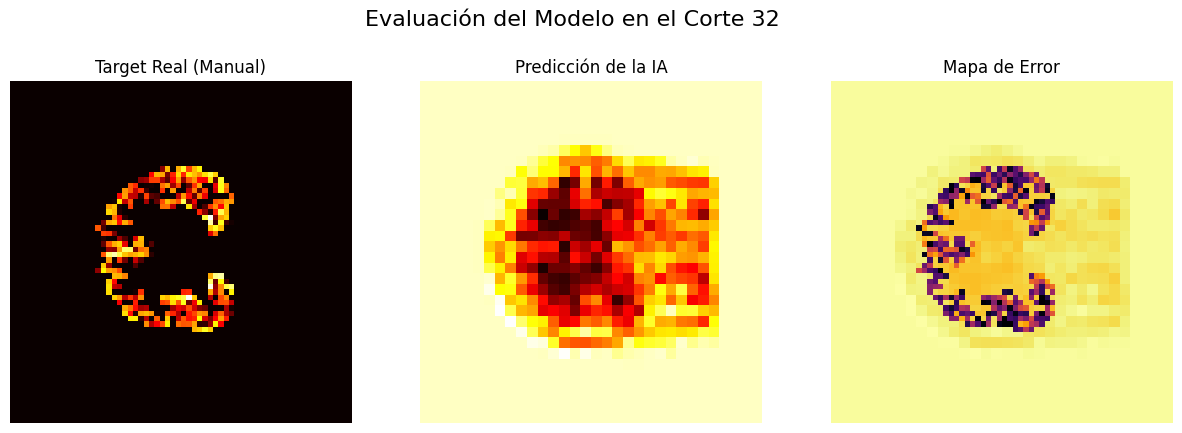

In [ ]:
# --- Evaluación de Resultados ---

def comparar_prediccion(slice_idx=32):
    plt.figure(figsize=(15, 5))

    # Target Real (lo que debería ser)
    plt.subplot(1, 3, 1)
    plt.imshow(Y[0, :, :, slice_idx, 0], cmap='hot')
    plt.title("Target Real (Manual)")
    plt.axis('off')

    # Predicción de la IA (lo que el modelo aprendió)
    plt.subplot(1, 3, 2)
    plt.imshow(prediccion[0, :, :, slice_idx, 0], cmap='hot')
    plt.title("Predicción de la IA")
    plt.axis('off')

    # Error (Diferencia entre ambos)
    error = np.abs(Y[0, :, :, slice_idx, 0] - prediccion[0, :, :, slice_idx, 0])
    plt.subplot(1, 3, 3)
    plt.imshow(error, cmap='inferno')
    plt.title("Mapa de Error")
    plt.axis('off')

    plt.suptitle(f"Evaluación del Modelo en el Corte {slice_idx}", fontsize=16)
    plt.show()

comparar_prediccion(32)

✅ En esta etapa final se realiza la validación de desempeño y contraste de hipótesis mediante la comparación de resultados en el corte 32. Aquí se evalúa la capacidad de generalización del modelo al enfrentar la "Verdad Absoluta" (Target Real) contra la "Predicción de la IA". La imagen central revela qué tan bien ha aprendido la red neuronal a reconstruir la morfología cerebral, mientras que el Mapa de Error es el indicador más crítico: resalta las zonas donde existen discrepancias entre la máscara manual y la automática, aunque el modelo captura la forma global, existen desafíos en la precisión de los bordes o detalles finos, lo que justifica la necesidad de métricas más avanzadas (como el Dice Coefficient) para cuantificar el éxito de la segmentación en un contexto clínico real.